In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
sns.set_style("white")
sns.set_style("ticks") 
from scipy.stats import sem
from scipy.stats import tstd
from sklearn.preprocessing import minmax_scale
from matplotlib.pyplot import cm

import json

from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

mpl.rcParams['image.interpolation']='none'

In [2]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell='None', RFP_check=True, subcell='None', label='None'):
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        
        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        
        stim_name = stim_list[i]
        print(Rep_name)
        if cell != 'None':
            Rep_name += '_'+cell
        if subcell != 'None':
            Rep_name += '_'+subcell
        
        GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
        if RFP_check==True:
            RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
        elif RFP_check==False:
            RFP = np.zeros(np.shape(GCaMP))

        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.5, window = 1311)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.5, window = 1311)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD' or cell == 'None':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
    
    if label=='None':
        label = 'min_'+Rep_name
    Aligned_data_Combined['Label'] = label
    
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.9, window = 1311, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 200): 
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    Response_frame = np.nan  # Initialize with NaN so if AFD never responds than output is NaN
    Response_temp = np.nan   # Initialize with NaN so if AFD never responds than output is NaN
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [3]:
def sort_matrix_for_heatmap(Delta):
    return(sorted(Delta, key = lambda row : max(row), reverse=True))

def plot_Delta(conditions_plot, heatmaps_plot, separate_temp = False, start_ind = 0, stop_ind = False, line_width = 1, figsize = 'Default', set_color = 'Default', xcolor = None, colorbar = False, save = None, sort = True, legend = True, temp_limits = None, Resp_limits = None):
    if stop_ind == False:
        stop_ind = len(conditions_plot[0]['Time'])
    plt.clf()
    ax_counter = 0
    if separate_temp == True:
        numrows = len(heatmaps_plot) + 2
    else:
        numrows = len(heatmaps_plot) + 1
    if figsize =='Default':
        fig,axs = plt.subplots(nrows=numrows,ncols=1,figsize=(10,numrows*4))#,dpi=300)#plt.ylim(0,1)
    else:
        fig,axs = plt.subplots(nrows=numrows,ncols=1, figsize = figsize )#,dpi=300)#plt.ylim(0,1)

    ax1 = plt.subplot(numrows,1,1)
    ax_counter += 1
    for i in conditions_plot:
        ax1.plot(i['Time'][start_ind:stop_ind], i['Temp'][start_ind:stop_ind], 'k')
        if xcolor is not None:
            for start, stop, col in xcolor:
                ax1.plot(i['Time'][start:stop], i['Temp'][start:stop], color=col, lw=line_width)
    
    ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
    ax1.set_xlabel('Time (s)', fontsize = 15)
    
    if temp_limits:
        ax1.set_ylim( temp_limits )
    else:
        ax1.set_ylim(min(conditions_plot[0]['Temp']) - 0.1 * abs(min(conditions_plot[0]['Temp'])), max(conditions_plot[0]['Temp']) + 0.1 * abs(max(conditions_plot[0]['Temp'])))
        
    ax1.set_xlim(min(conditions_plot[0]['Time'][start_ind:stop_ind]),max(conditions_plot[0]['Time'][start_ind:stop_ind]))
    if legend == True:
        ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)
    if separate_temp == True:
        ax2 = plt.subplot(numrows,1,2)
        ax_counter += 1
    else:
        ax2 = ax1.twinx()
    for i in conditions_plot:
        if set_color == 'Default':
            ax2.plot(i['Time'][start_ind:stop_ind], i['Mean_Delta'][start_ind:stop_ind], lw=line_width, label = i['Label'])
        else:
            ax2.plot(i['Time'][start_ind:stop_ind], i['Mean_Delta'][start_ind:stop_ind], lw=line_width, color = set_color, label = i['Label'])
 
    if legend == True:
        ax2.legend(fontsize = 15)#, loc='upper right')
    for i in conditions_plot:
        if set_color == 'Default':
            ax2.fill_between(i['Time'][start_ind:stop_ind], i['Std_low_Delta'][start_ind:stop_ind], i['Std_high_Delta'][start_ind:stop_ind], alpha=0.4)
        else:
            ax2.fill_between(i['Time'][start_ind:stop_ind], i['Std_low_Delta'][start_ind:stop_ind], i['Std_high_Delta'][start_ind:stop_ind], color = set_color, alpha=0.4)
    ax2.set_ylabel('Delta R/R', fontsize = 15)
    
    if Resp_limits:
        ax2.set_ylim( Resp_limits ) 
    else:
        ax2.set_ylim(ymin=0) 

    ax2.set_xlim(min(conditions_plot[0]['Time'][start_ind:stop_ind]),max(conditions_plot[0]['Time'][start_ind:stop_ind]))
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)

    #plt.title('AFD Ca++ Signal Across TCs', fontsize = 15)
    # HEATMAP ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    if heatmaps_plot is not None:
        heatmap_min = 0
        heatmap_max = 0
        aspect = 0
        for i in heatmaps_plot:
            if len(i['Delta']) > aspect:
                aspect = len(i['Delta'])
            if np.min(i['Delta'][:,start_ind:stop_ind]) < heatmap_min:
                heatmap_min = np.min(i['Delta'][:,start_ind:stop_ind])
            if np.max(i['Delta'][:,start_ind:stop_ind]) > heatmap_max:
                heatmap_max = np.max(i['Delta'][:,start_ind:stop_ind])
        for i in heatmaps_plot:
            ax_counter += 1
            ax = plt.subplot(numrows,1,ax_counter)
            if sort == True:
                sorted_Delta = sort_matrix_for_heatmap(i['Delta'][:,start_ind:stop_ind])
                #heatmap = ax.imshow(sorted_Delta, cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/len(sorted_Delta))*(0.35))
                heatmap = ax.imshow(sorted_Delta, cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/aspect)*(0.35))
            else:
                #heatmap = ax.imshow(i['Delta'][:,start_ind:stop_ind], cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/len(i['Delta']))*(0.35))
                heatmap = ax.imshow(i['Delta'][:,start_ind:stop_ind], cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/aspect)*(0.35))
            if colorbar == True:
                fig.colorbar(heatmap, ax=ax)
            heat_label = ax.set_title(i['Label'], fontdict={'fontsize': 15})
            ax.tick_params(axis='x', colors='white')
            #heat_label.set_color("white")
            plt.tick_params(axis='both', which='major', labelsize=15)
            plt.tick_params(axis='both', which='minor', labelsize=15)
    
    plt.tight_layout()
    if save is not None:
            plt.savefig(save, dpi=600, bbox_inches='tight')
    
    plt.show()
    plt.close()

# Loading Data - Temperature Derivative Based Stimuli

In [4]:
# RAMP 21.5-->22.5

pref1 = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220404a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1/"
pref2 = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220405a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1/"

pref3 = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220217a_WyIs629_Tc25_5RampSteps_20to21__1/"
pref4 = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220218b_WyIs629_Tc25_Ramp20to21steps__1/"

p = 'C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Jon_Upsteps/'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~  Longer_dt   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

DCR3055_Tc25_Longer_dt_meta = [ pref1 + '220404a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1', pref2 + '220405a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1'
                    ]
DCR3055_Tc25_Longer_dt_stim = [ pref1 + '040422_221455_887', pref2 + '040522_221830_380' ]
DCR3055_Tc25_Longer_dt = load_GCaMP_RFP_meta_stim(DCR3055_Tc25_Longer_dt_meta, DCR3055_Tc25_Longer_dt_stim, label = 'Tc25 Longer dt', RFP_check=True)

#-----------------------------------------------------  Longer_dT   --------------------------------------------------------------------------------

DCR3055_Tc25_Longer_dT_meta = [ pref3 + '220217a_WyIs629_Tc25_5RampSteps_20to21__1', pref4 + '220218b_WyIs629_Tc25_Ramp20to21steps__1'
                    ]
DCR3055_Tc25_Longer_dT_stim = [ pref3 + '021722_201237_503', pref4 + '021822_190712_280' ]
DCR3055_Tc25_Longer_dT = load_GCaMP_RFP_meta_stim(DCR3055_Tc25_Longer_dT_meta, DCR3055_Tc25_Longer_dT_stim, label = 'Tc25 100 Post Fix', RFP_check=True)


#-----------------------------------------------------  Continuous Upramps   --------------------------------------------------------------------------------

Ramp_meta = [p+'091321_3055_Model_StepRamps_Tc25_A_1']
Ramp_stim = [p+'091321_145003_198']
#Ramp_Axon = load_GCaMP_RFP_meta_stim(Ramp_meta, Ramp_stim,  'Axon')
Ramp_Soma = load_GCaMP_RFP_meta_stim(Ramp_meta, Ramp_stim, 'AFD', subcell = 'soma', label = 'Soma')
#Ramp_Sense = load_GCaMP_RFP_meta_stim(Ramp_meta, Ramp_stim,  'Dendrite')


MicroManager v1
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220404a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1/220404a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
missed end
Done
MicroManager v1
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Analysis_220405a_WyIs629_Tc25_hold20_21p2degC_1to5minRamps_1_1/220405a_WyIs629_Tc25_hold20_21p2degC_1to5

MicroManager v1
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Reproducing Ernesto Data/Jon_Upsteps/091321_3055_Model_StepRamps_Tc25_A_1
Done


[0.24629404040465303, 0.5201984661789092, 1.4705280249637294, 2.6038377987257375, 2.9318928320023967, 2.503168000350943]
[0.8009496792069278, 2.6694469775880423, 2.34937489634498, 2.152242545919137, 1.7835242498243242, 1.4356665933611845]


<Figure size 640x480 with 0 Axes>

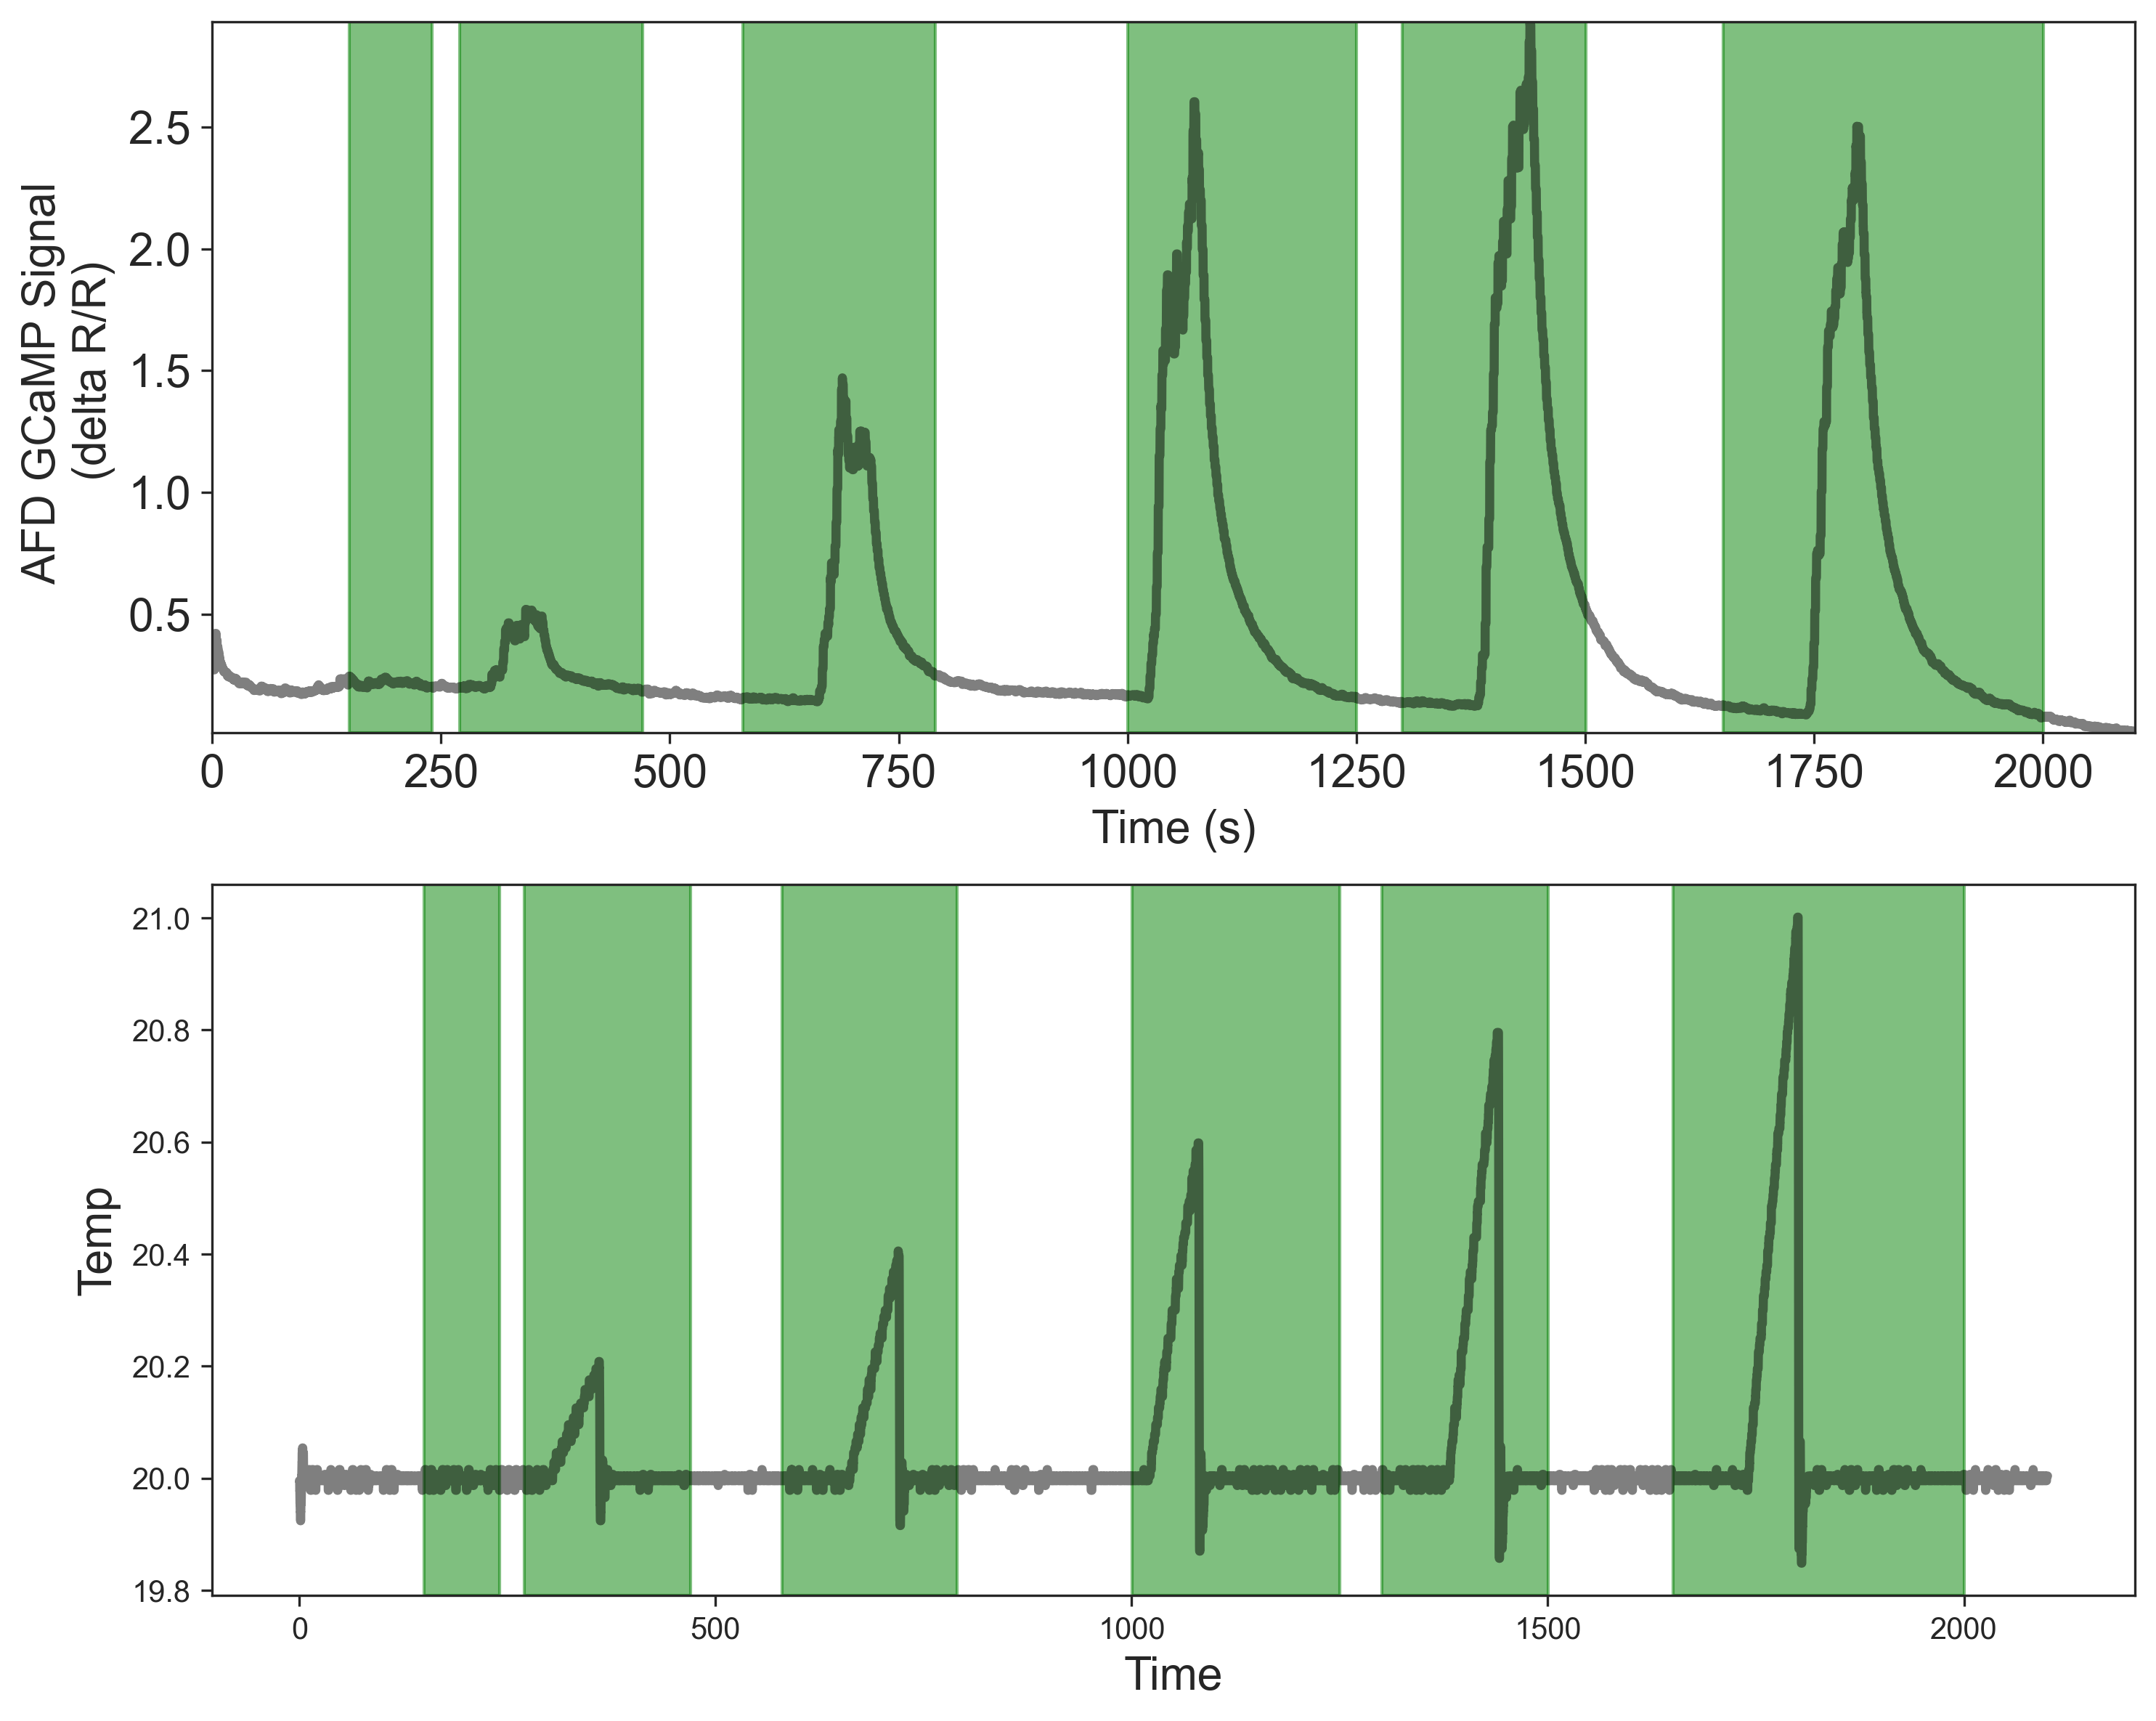

<Figure size 640x480 with 0 Axes>

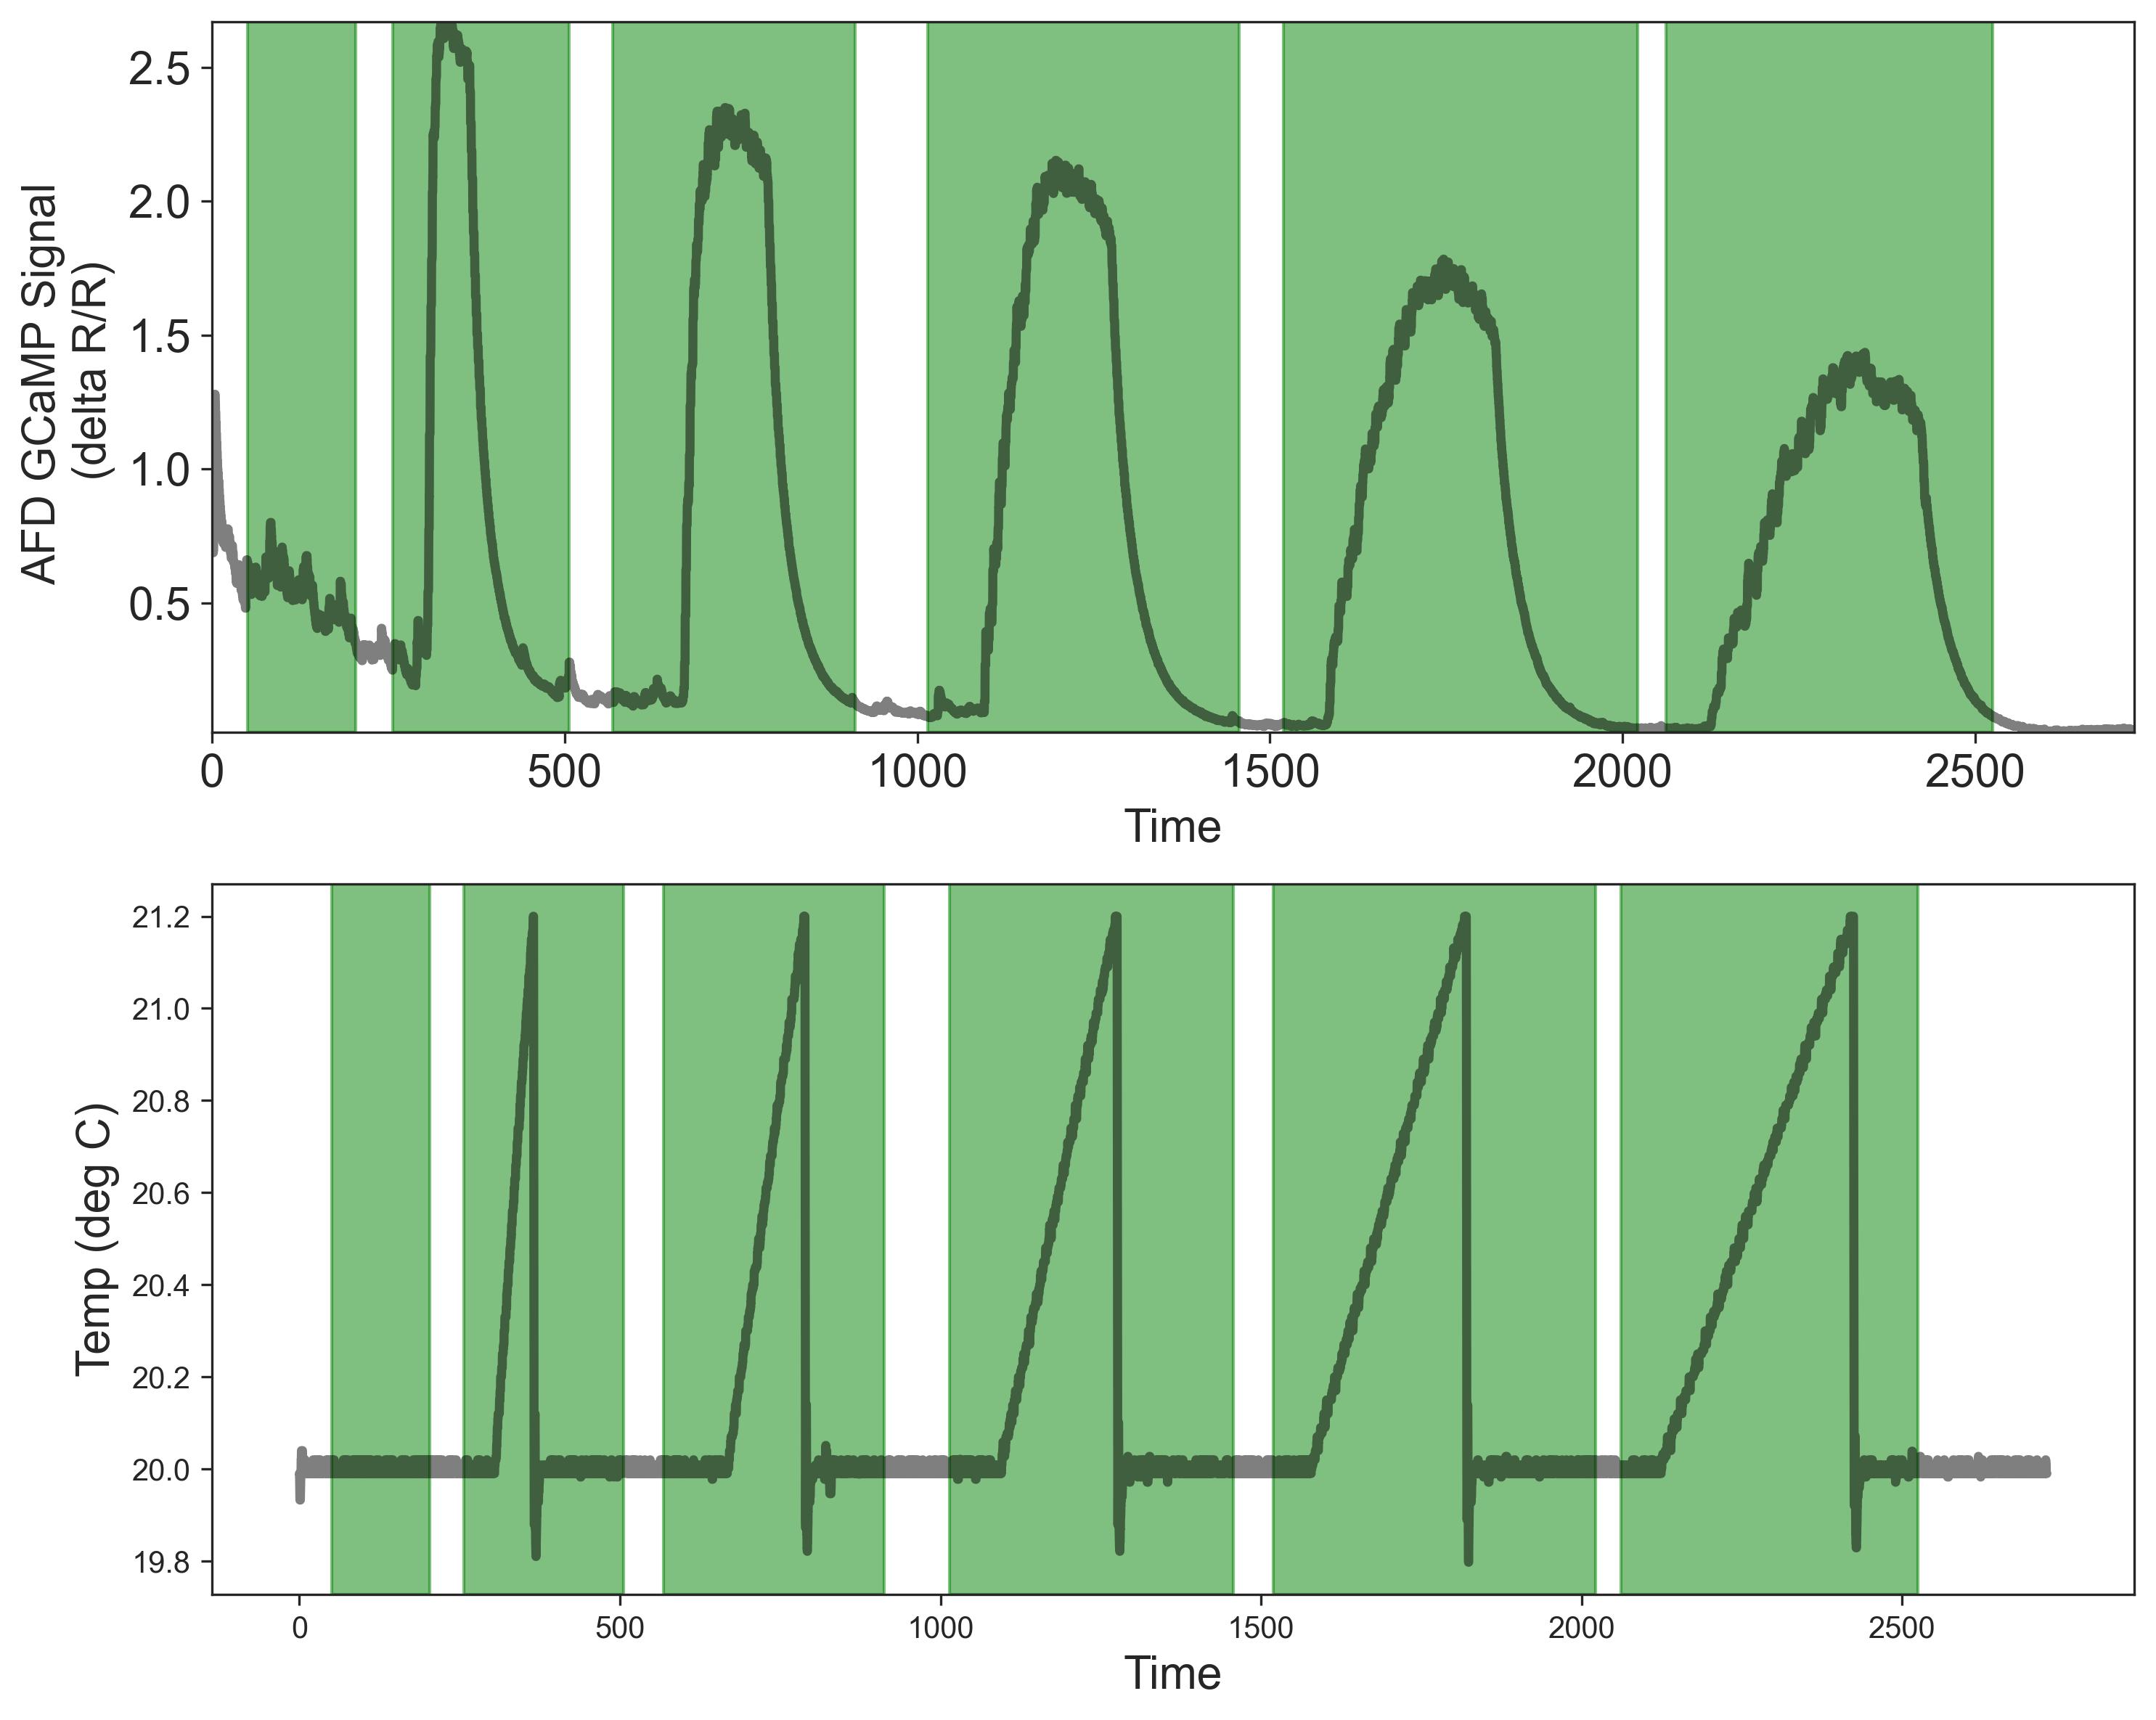

<Figure size 640x480 with 0 Axes>

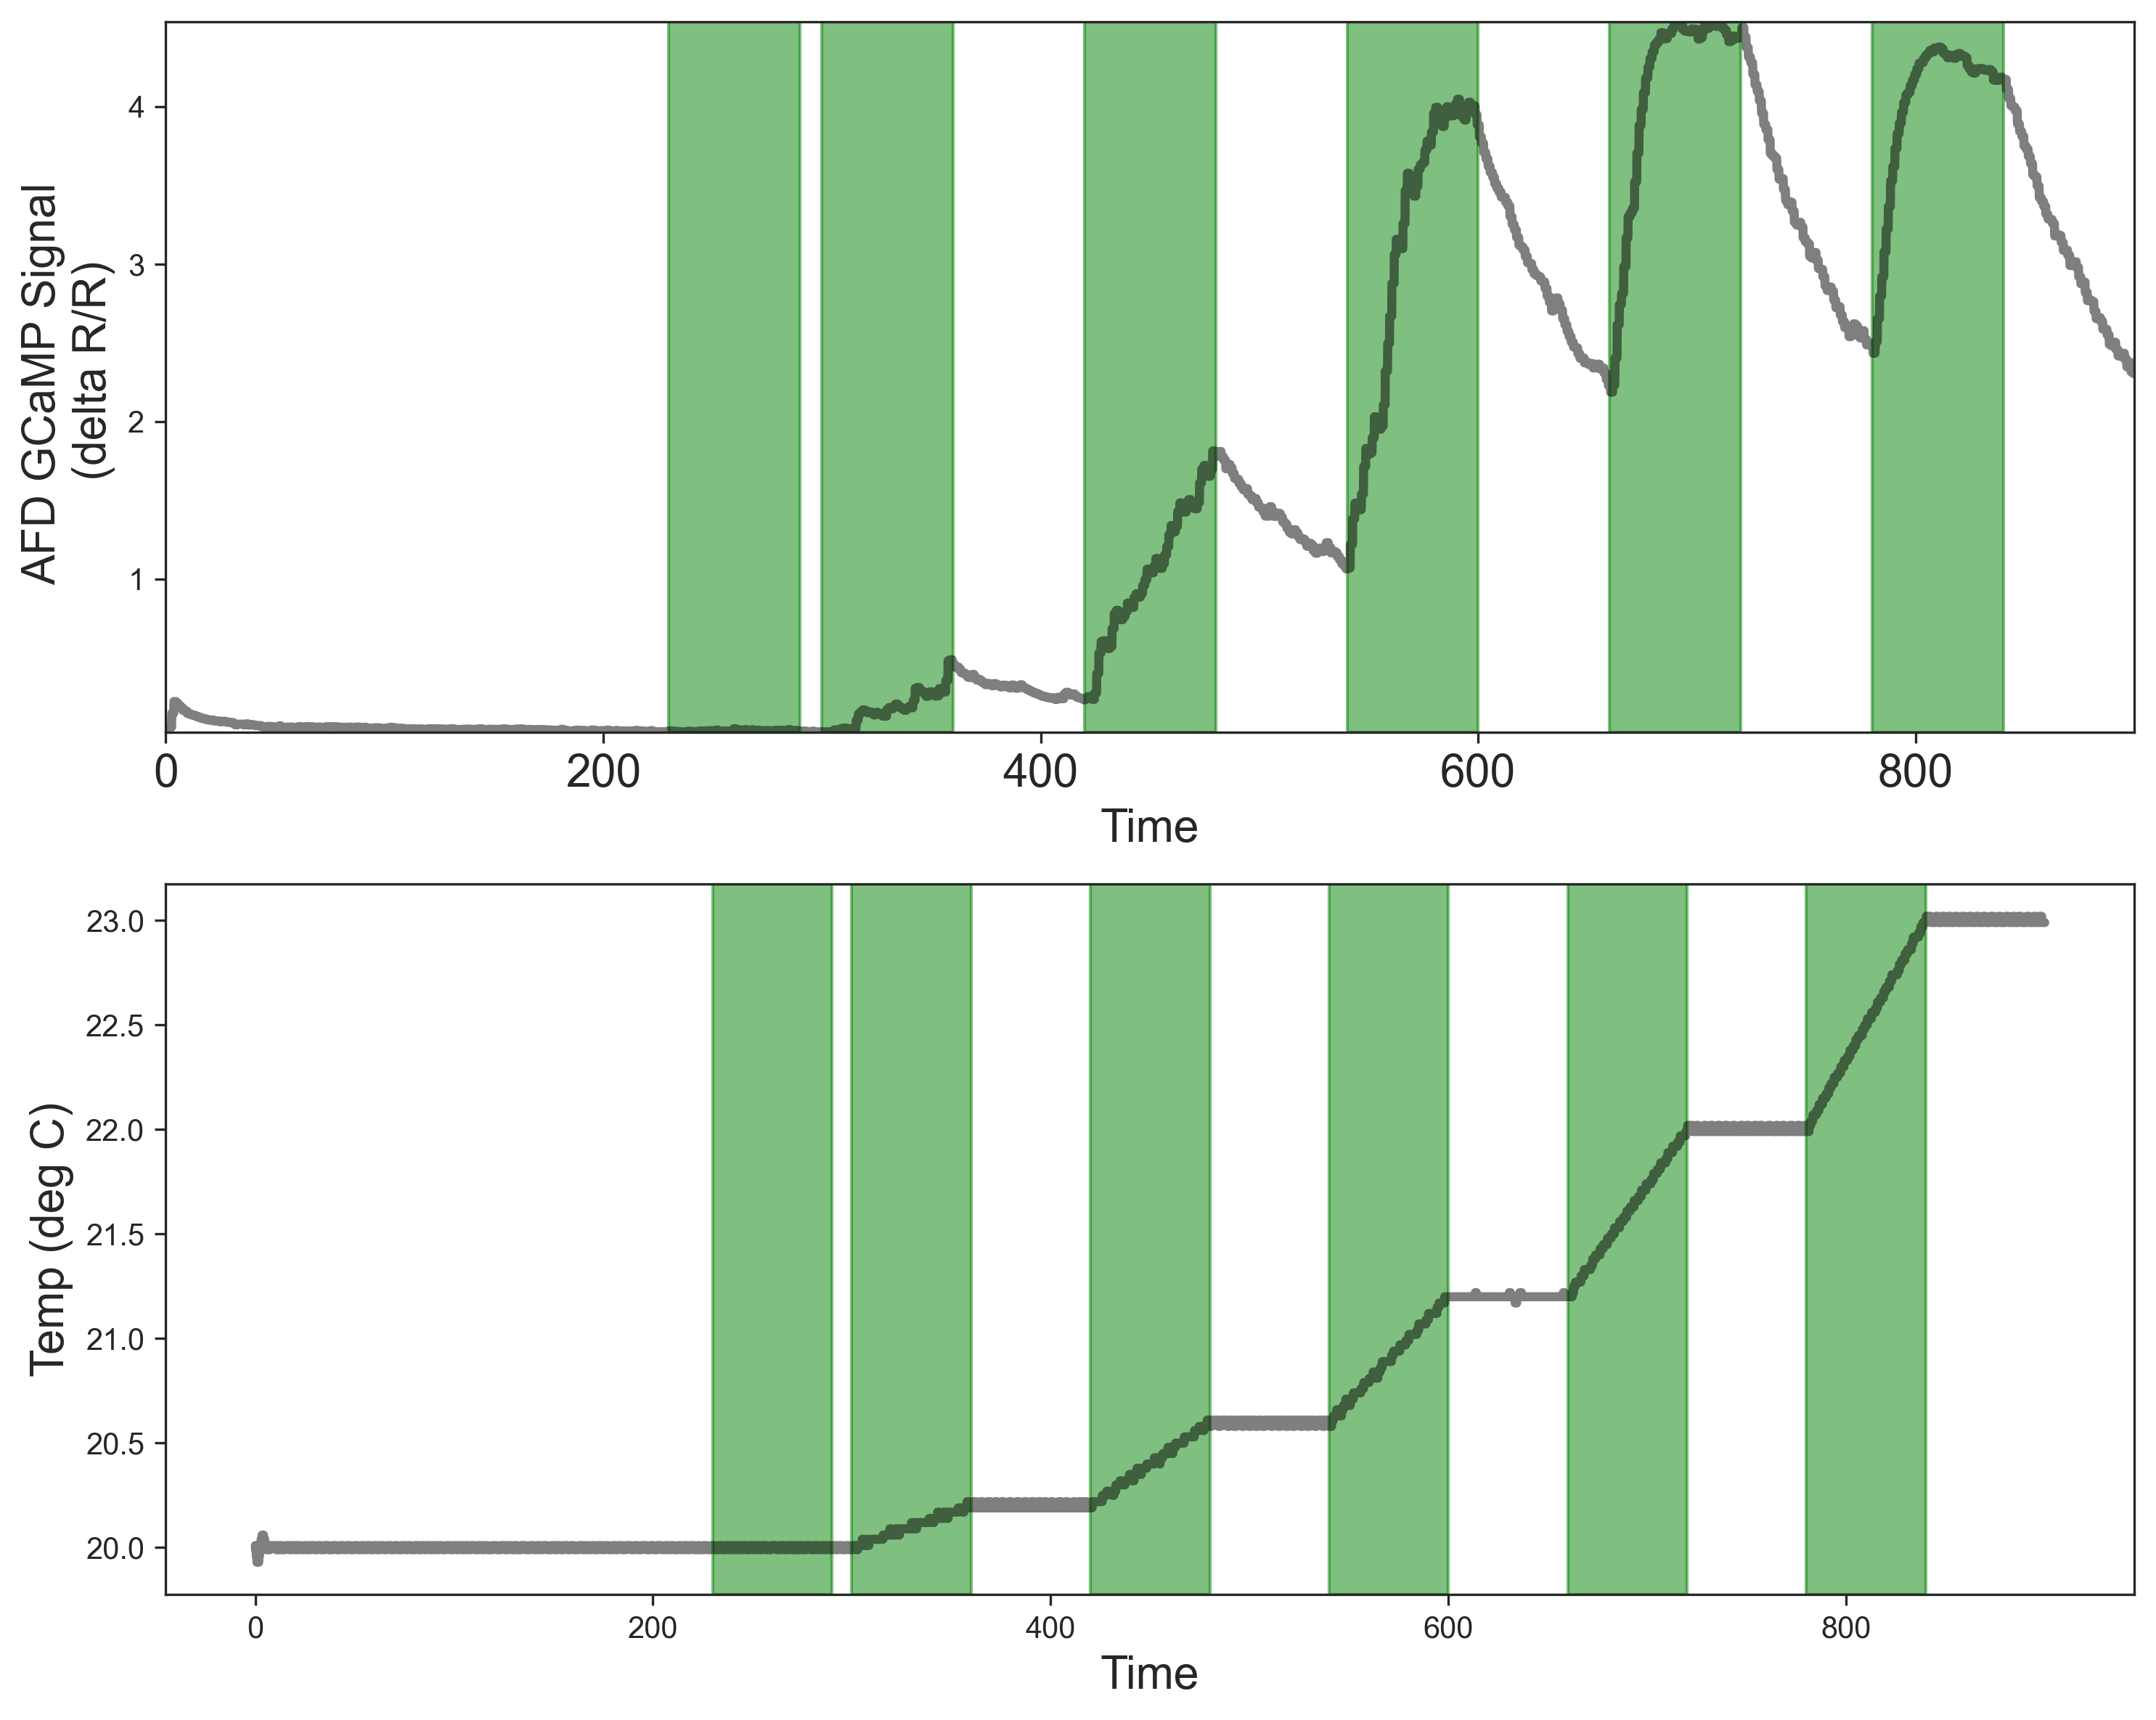

In [7]:

ranges_dT = [ (1500,2400), (2700,4700), (5800,7900), (10000,12500), (13000,15000), (16500,20000) 
             ]
ranges_dt = [ (500,2000), (2520,5000), (5620,9000), (10020,14400), (15020,20000), (20400,25000)  
             ]

ranges_step = [ (2300,2900), (3000,3600), (4200,4800), (5400,6000), (6600,7200), (7800,8400)  
             ]

longer_dT_max_Resps = [
    float(max(DCR3055_Tc25_Longer_dT['Mean_Delta'][start:stop]))
    for start, stop in ranges_dT
]

longer_dt_max_Resps = [
    float(max(DCR3055_Tc25_Longer_dt['Mean_Delta'][start:stop]))
    for start, stop in ranges_dt
]

longer_step_max_Resps = [
    float(max(Ramp_Soma['Mean_Delta'][start:stop]))
    for start, stop in ranges_step
]

stims_dT = [ 0, 0.2, 0.4, 0.6, 0.8, 1.0 ]
stims_dt = [ 0, 1.2, 1.2/2, 1.2/3, 1.2/4 , 1.2/5 ]
stims_step = [ 0, 0.2, 0.4, 0.6, 0.8, 1.0 ]

print(longer_dT_max_Resps)

print(longer_dt_max_Resps)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# deriv Temp up
plt.clf()
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(10,8),dpi=300)
ax2 = plt.subplot(2,1,1)

ax2.plot(DCR3055_Tc25_Longer_dT['Time'], DCR3055_Tc25_Longer_dT['Mean_Delta'], c='k', lw=3, alpha=0.5)
ax1 = plt.subplot(2,1,2)
ax1.plot(DCR3055_Tc25_Longer_dT['Time'], DCR3055_Tc25_Longer_dT['Temp'], c='k', lw=3, alpha=0.5)


for i in ranges_dT:
    ax1.axvspan(DCR3055_Tc25_Longer_dT['Time'][ i[0] ], DCR3055_Tc25_Longer_dT['Time'][ i[1] ],alpha=0.5,color='green', label='selection')
    ax2.axvspan(DCR3055_Tc25_Longer_dT['Time'][ i[0] ], DCR3055_Tc25_Longer_dT['Time'][ i[1] ],alpha=0.5,color='green', label='selection')

ax1.set_ylabel('Temp', fontsize=15)
ax1.set_xlabel('Time', fontsize=15)
ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(DCR3055_Tc25_Longer_dT['Time']),xmax=max(DCR3055_Tc25_Longer_dT['Time']))
ax2.set_ylim(ymin=min(DCR3055_Tc25_Longer_dT['Mean_Delta']),ymax=max(DCR3055_Tc25_Longer_dT['Mean_Delta']))
ax2.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)


#ax2.legend(fontsize=15)
plt.tight_layout()
plt.show()
plt.close()
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# deriv Time up
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(10,8),dpi=300)
ax1 = plt.subplot(2,1,1)
ax1.plot(DCR3055_Tc25_Longer_dt['Time'], DCR3055_Tc25_Longer_dt['Mean_Delta'], c='k', lw=3, alpha=0.5)
ax2 = plt.subplot(2,1,2)
ax2.plot(DCR3055_Tc25_Longer_dt['Time'], DCR3055_Tc25_Longer_dt['Temp'], c='k', lw=3, alpha=0.5)

for i in ranges_dt:
    ax1.axvspan(DCR3055_Tc25_Longer_dt['Time'][ i[0] ], DCR3055_Tc25_Longer_dt['Time'][ i[1] ],alpha=0.5,color='green', label='selection')
    ax2.axvspan(DCR3055_Tc25_Longer_dt['Time'][ i[0] ], DCR3055_Tc25_Longer_dt['Time'][ i[1] ],alpha=0.5,color='green', label='selection')
    
ax1.tick_params(axis='y' )
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis = 'both', labelsize=15) #
ax1.set_xlim(xmin=min(DCR3055_Tc25_Longer_dt['Time']),xmax=max(DCR3055_Tc25_Longer_dt['Time']))
ax1.set_ylim(ymin=min(DCR3055_Tc25_Longer_dt['Mean_Delta']),ymax=max(DCR3055_Tc25_Longer_dt['Mean_Delta']))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15 )
ax1.set_xlabel('Time', fontsize=15)
ax2.set_ylabel('Temp (deg C)', fontsize=15)
ax2.set_xlabel('Time', fontsize=15)

#ax1.legend(fontsize=15)
plt.tight_layout()
plt.show()
plt.close()

    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Temp UPSTEPS

plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(10,8),dpi=300)
ax1 = plt.subplot(2,1,1)
ax1.plot(Ramp_Soma['Time'], Ramp_Soma['Mean_Delta'], c='k', lw=3, alpha=0.5)
ax2 = plt.subplot(2,1,2)
ax2.plot(Ramp_Soma['Time'], Ramp_Soma['Temp'], c='k', lw=3, alpha=0.5)

for i in ranges_step:
    ax1.axvspan(Ramp_Soma['Time'][ i[0] ], Ramp_Soma['Time'][ i[1] ],alpha=0.5,color='green', label='selection')
    ax2.axvspan(Ramp_Soma['Time'][ i[0] ], Ramp_Soma['Time'][ i[1] ],alpha=0.5,color='green', label='selection')
    
ax1.tick_params(axis='y' )
ax1.tick_params(axis='x', labelsize=15)
ax1.set_xlim(xmin=min(Ramp_Soma['Time']),xmax=max(Ramp_Soma['Time']))
ax1.set_ylim(ymin=min(Ramp_Soma['Mean_Delta']),ymax=max(Ramp_Soma['Mean_Delta']))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15 )
ax1.set_xlabel('Time', fontsize=15)
ax2.set_ylabel('Temp (deg C)', fontsize=15)
ax2.set_xlabel('Time', fontsize=15)

#ax1.legend(fontsize=15)
plt.tight_layout()
plt.show()
plt.close()


# Plots

## Temp & Calcium

<Figure size 640x480 with 0 Axes>

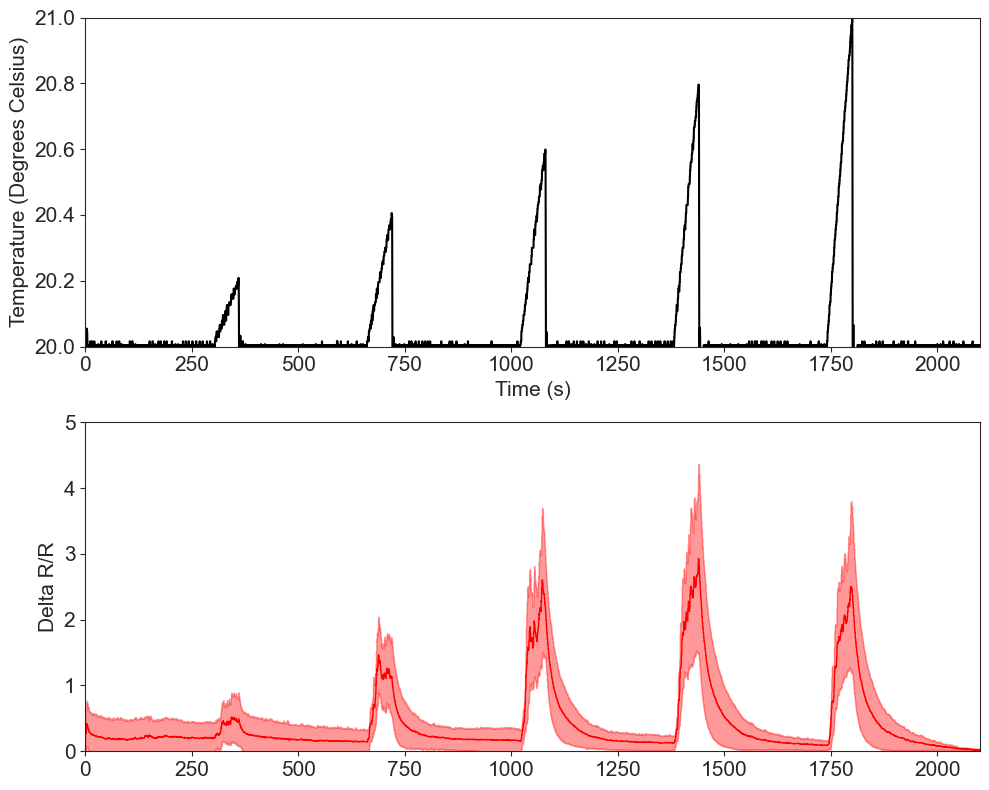

In [17]:
temp_limits = [20, 21.0]
Resp_limits = [0, 5]
conditions_plot = [ DCR3055_Tc25_Longer_dT ]
#heatmaps_plot = [ DCR3055_Tc25_Longer_dT ]
heatmaps_plot = [  ]
#save2 = 'Z:/Malcom/Jon Ca Plots Output/dTempchange_output.pdf'
save2 = None
figsize = (10,8)
#plot_Delta(conditions_plot, heatmaps_plot, set_color= 'r', temp_limits = temp_limits, save = save, Resp_limits = Resp_limits, legend=False)
plot_Delta(conditions_plot, heatmaps_plot, set_color= 'r', figsize = figsize, temp_limits = temp_limits, save = save2, Resp_limits = Resp_limits, legend=False, separate_temp=True)

<Figure size 640x480 with 0 Axes>

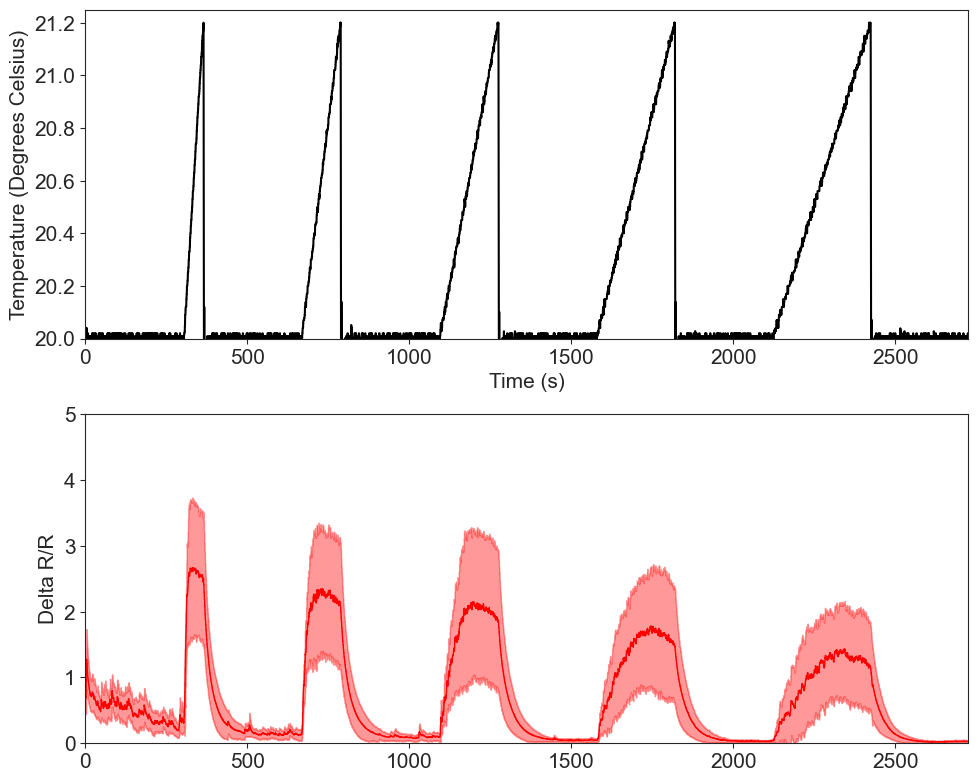

In [16]:
temp_limits = [20, 21.25]
Resp_limits = [0, 5]
conditions_plot = [ DCR3055_Tc25_Longer_dt ]
#heatmaps_plot = [ DCR3055_Tc25_Longer_dt ]
heatmaps_plot = []
#save1 = 'Z:/Malcom/Jon Ca Plots Output/dtimechange_output_SM.pdf'
save1 = None
figsize = (10,8)
plot_Delta(conditions_plot, heatmaps_plot, set_color= 'r', figsize = figsize, temp_limits = temp_limits, save = save1, Resp_limits = Resp_limits, legend=False, separate_temp=True)

<Figure size 640x480 with 0 Axes>

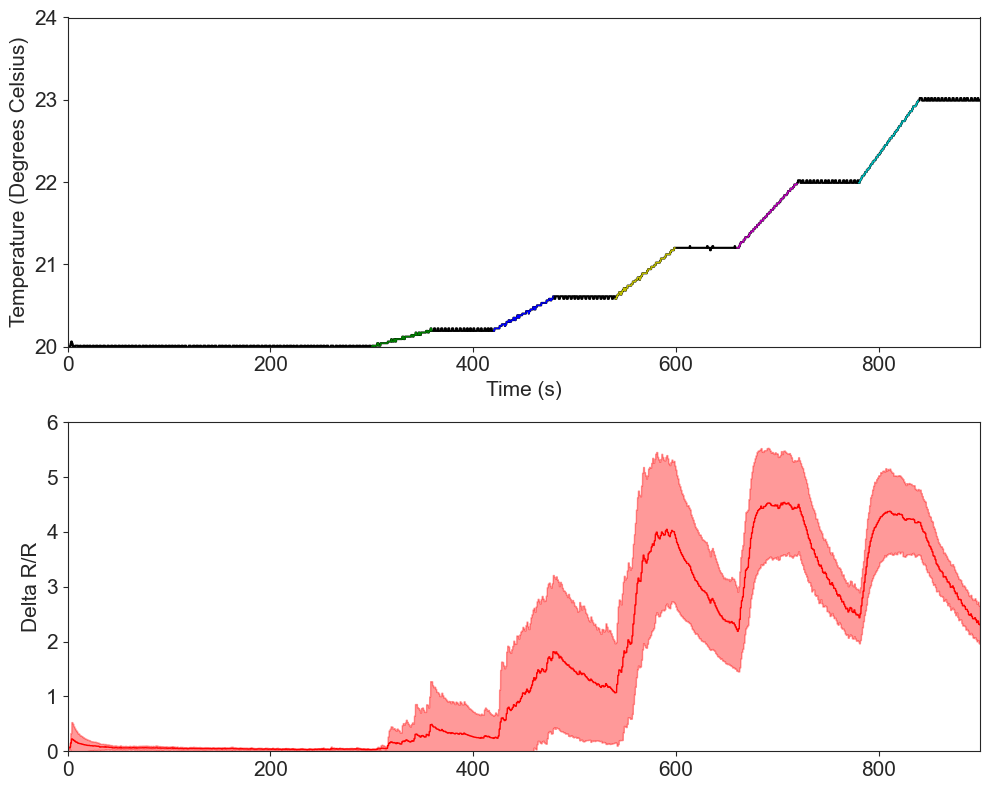

In [22]:
temp_limits = [20, 24.0]
Resp_limits = [0, 6]
conditions_plot = [ Ramp_Soma ]
heatmaps_plot = [  ]

segments = [(0,3000,'k'), (3000,3600,'g'), (3600,4200,'k'),
            (4200,4800,'b'), (4800,5400,'k'), (5400,6000,'y'),
            (6000,6600,'k'), (6600,7200,'m'), (7200,7800,'k'),
            (7800,8400,'c'), (8400,9000,'k')]


    
plot_Delta(conditions_plot, heatmaps_plot, set_color= 'r', figsize = figsize, temp_limits = temp_limits, save = None, Resp_limits = Resp_limits, legend=False, xcolor = segments, separate_temp=True)



## Calcium Level vs Derivative

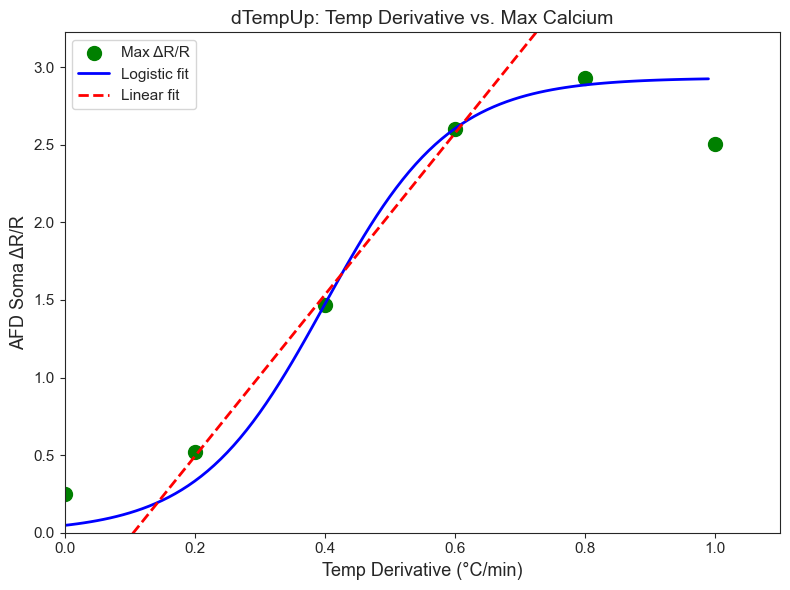

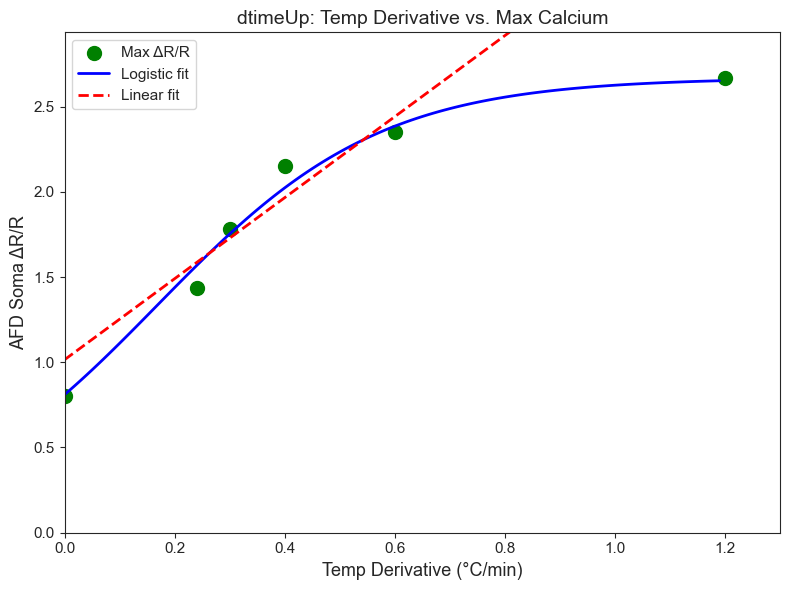

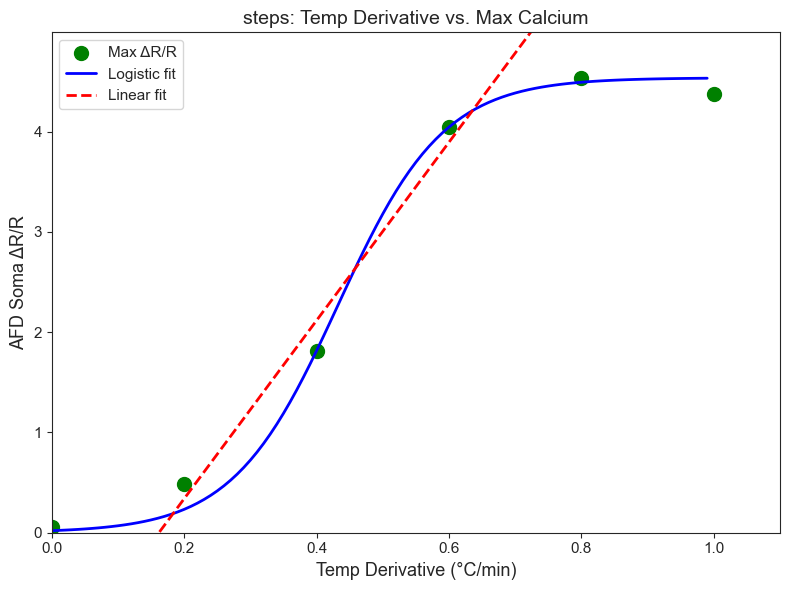

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def plot_stimulus_response(derivs,
                           responses,
                           scale_responses=True,
                           log_fit_range=(0.2, 0.8),
                           lin_fit_range=(0.2, 0.6),
                           plot_only=False,
                           save = None,
                           title=""):
    """
    derivs            : list/array of your derivatives, e.g. [0,0.2,0.4,0.6,0.8,1.0]
    responses         : list/array of max ΔR/R in each stimulus
    scale_responses   : if True, normalize `responses` so max→1 before the logistic fit
    log_fit_range     : (min, max) of derivs to include in the LOGISTIC fit
    lin_fit_range     : (min, max) of derivs to include in the LINEAR fit
    plot_only         : if True, skip fitting and just plot the chosen response series
    title             : plot title (e.g. 'dT' or 'dt')
    """
    x_all = np.array(derivs)
    y_all = np.array(responses)

    # 1) scale if requested
    if scale_responses:
        y_fit = y_all / y_all.max()
    else:
        y_fit = y_all.copy()

    # If only plotting
    if plot_only:
        plt.figure(figsize=(8,6))
        plt.scatter(x_all, y_fit, s=100, c='g')           # green points
        #plt.plot(x_all, y_fit, '-', c='g')                # green line
        plt.title(f'{title}: {"Scaled" if scale_responses else "Raw"} Response', fontsize=14)
        plt.xlabel('Temp Derivative (°C/min)', fontsize=13)
        plt.ylabel('ΔR/R', fontsize=13)
        plt.xlim(x_all.min(), x_all.max()+0.1)
        plt.ylim(0, y_fit.max()*1.1)
        plt.xticks(fontsize=11)
        plt.yticks(fontsize=11)
        plt.tight_layout()
        plt.show()
        return

    # 2) logistic‐fit subset
    mask_log = (x_all >= log_fit_range[0]) & (x_all <= log_fit_range[1])
    x_log = x_all[mask_log].reshape(-1,1)
    y_log = y_fit[mask_log].reshape(-1,1)
    eps = 1e-6
    y_log = np.clip(y_log, eps, 1 - eps)
    y_logit = np.log((1 / y_log) - 1)
    log_model = LinearRegression().fit(x_log, y_logit)
    α_log = log_model.coef_[0,0]
    β_log = log_model.predict([[0]])[0,0]

    # 3) linear‐fit subset
    mask_lin = (x_all >= lin_fit_range[0]) & (x_all <= lin_fit_range[1])
    x_lin = x_all[mask_lin].reshape(-1,1)
    y_lin = y_all[mask_lin]
    lin_model = LinearRegression().fit(x_lin, y_lin)
    α_lin = lin_model.coef_[0]
    β_lin = lin_model.predict([[0]])[0]

    # 4) sampling for smooth curves
    x_samp = np.arange(x_all.min(), x_all.max(), 0.01)
    frac    = 1 / (1 + np.exp(α_log * x_samp + β_log))
    y_pred_log = frac * y_all.max()
    y_pred_lin = α_lin * x_samp + β_lin

    # 5) plot with your requested colors
    plt.figure(figsize=(8,6))
    plt.scatter(x_all, y_all,    s=100, c='g', label='Max ΔR/R')       # green
    plt.plot(x_samp, y_pred_log,  '-', c='b', lw=2, label='Logistic fit')  # blue
    plt.plot(x_samp, y_pred_lin,  'r--', lw=2, label='Linear fit')        # red dashed

    plt.title(f'{title}: Temp Derivative vs. Max Calcium', fontsize=14)
    plt.xlabel('Temp Derivative (°C/min)', fontsize=13)
    plt.ylabel('AFD Soma ΔR/R', fontsize=13)
    plt.xlim(x_all.min(), x_all.max()+0.1)
    plt.ylim(0, y_all.max()*1.1)
    plt.legend(fontsize=11)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    
    if save == "svg":
        plt.savefig(f'{title}_stimulus_MaxRespFit.svg', dpi=600, bbox_inches='tight')
    elif save == "pdf":
        plt.savefig(f'{title}_stimulus_MaxRespFit.pdf', dpi=600, bbox_inches='tight')
    elif save == "png":
        plt.savefig(f'{title}_stimulus_MaxRespFit.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    

plot_stimulus_response(
    derivs          = stims_dT,
    responses       = longer_dT_max_Resps,
    scale_responses = True,
    log_fit_range   = (0.4, 0.6),
    lin_fit_range   = (0.2, 0.6),
    save = "svg",
    title           = 'dTempUp'
)

plot_stimulus_response(
    derivs          = stims_dt,
    responses       = longer_dt_max_Resps,
    scale_responses = True,
    log_fit_range   = (0.2, 0.8),
    lin_fit_range   = (0.1, 0.6),
    save = "svg",
    title           = 'dtimeUp'
)

plot_stimulus_response(
    derivs          = stims_step,
    responses       = longer_step_max_Resps,
    scale_responses = True,
    log_fit_range   = (0.4, 0.6),
    lin_fit_range   = (0.2, 0.6),
    save = "svg",
    title           = 'steps'
)


# Peak Significance

In [5]:
# Just peak height, not prominence, uses simple max Calcium to get peaks
import numpy as np
import pandas as pd

def get_step_responses_across_replicates(neuron, ranges_step, stim_mapping):
    """
    Calculates the peak (maximum) response within specific index windows 
    for every replicate, using absolute indexing.
    """
    # 1. Extract Data
    Time = np.asarray(neuron['Time']).flatten()
    Temp = np.asarray(neuron['Temp']).flatten()
    Delta_Matrix = np.asarray(neuron['Delta'])
    
    n_timepoints = len(Time)
    shape = Delta_Matrix.shape
    
    # 2. Determine Orientation
    if shape[1] == n_timepoints:
        num_replicates = shape[0]
        get_trace = lambda i: Delta_Matrix[i, :] # Row
    elif shape[0] == n_timepoints:
        num_replicates = shape[1]
        get_trace = lambda i: Delta_Matrix[:, i] # Column
    else:
        raise ValueError(f"Delta shape {shape} does not match Time length {n_timepoints}")

    all_responses = []

    # 3. Loop Replicates
    for rep_idx in range(num_replicates):
        y_full = get_trace(rep_idx).copy()
        
        # Stability Shift
        y_min = np.min(y_full)
        if y_min < 0:
            y_full = y_full - y_min

        # 4. Loop Index Ranges
        for step_idx, (start_idx, end_idx) in enumerate(ranges_step):
            
            # Bounds check
            if start_idx >= n_timepoints:
                continue
            
            # Slice the specific window to find the max
            y_window = y_full[start_idx:end_idx]
            
            if len(y_window) == 0: 
                continue

            # A. Find relative index in the slice (0 to window_length)
            rel_idx = np.argmax(y_window)
            
            # B. Convert immediately to ABSOLUTE INDEX (0 to total_length)
            abs_peak_idx = start_idx + rel_idx
            
            # C. Use Absolute Index to grab data from the main arrays
            peak_val = y_full[abs_peak_idx]
            peak_time = Time[abs_peak_idx]
            peak_temp = Temp[abs_peak_idx]
            
            all_responses.append({
                'Replicate_ID': rep_idx + 1,
                'Step_ID': step_idx + 1,
                'Peak_Height': peak_val,
                'Peak_Time': peak_time,
                'Peak_Temp': peak_temp,
                'Absolute_Index': abs_peak_idx 
            })
    all_responses = pd.DataFrame(all_responses)
    all_responses['Step_Label'] = all_responses['Step_ID'].map(stim_mapping)
    return all_responses

In [18]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
# USES FRIEDMAN TEST FOR MAIN EFFECT, THEN WILCOXON SIGNED-RANK TEST FOR POST-HOC PAIRWISE COMPARISONS WITH HOLM-BONFERRONI CORRECTION (STEP-DOWN METHOD)
# ADDED FEATURE: Can specify a reference label (e.g. "0.0") to only compare that group against all others, which drastically reduces the number of comparisons and increases power for detecting differences from baseline.
# ADDED FEATURE: Can specify certain labels to exclude from the analysis (e.g. "0.0" baseline) to reduce the number of comparisons and increase power for detecting differences among the actual stimuli.

def perform_repeated_measures_analysis(df, subject_col='Replicate_ID', time_col='Step_Label', value_col='Peak_Height', exclude_labels=None, reference_label=None):
    """
    Performs Friedman + Wilcoxon (Holm) analysis.
    
    Parameters:
    - exclude_labels: List of strings to drop BEFORE analysis.
    - reference_label: If set (e.g. '0.0'), ONLY compares this group against others.
                       Drastically increases power by reducing comparisons.
    """
    print(f"--- Repeated Measures Analysis (Friedman + Wilcoxon-Holm) ---")
    
    # 1. Pivot Data to Wide Format
    df_pivot = df.pivot(index=subject_col, columns=time_col, values=value_col)
    original_n = len(df_pivot)
    df_clean = df_pivot.dropna()
    final_n = len(df_clean)
    
    if original_n != final_n:
        print(f"Warning: Dropped {original_n - final_n} subjects due to missing data.")
    
    # Sort columns numerically
    try:
        cols = sorted(df_clean.columns, key=lambda x: float(x))
    except:
        cols = sorted(df_clean.columns)

    # --- Exclude Specific Labels ---
    if exclude_labels:
        print(f"   -> Excluding columns: {exclude_labels}")
        cols = [c for c in cols if c not in exclude_labels]

    if reference_label and reference_label not in cols:
        print(f"Error: Reference label '{reference_label}' not found in data.")
        return

    df_clean = df_clean[cols]

    # 2. Main Test: Friedman
    print("\n1. Main Test (Friedman):")
    print(f"   Comparing groups: {cols}")
    data_arrays = [df_clean[col].values for col in cols]
    stat, p_val = stats.friedmanchisquare(*data_arrays)
    
    print(f"   - Statistic={stat:.3f}, p-value={p_val:.2e}")
    
    if p_val >= 0.05:
        print("   -> No Significant Difference found.")
        return

    print("   -> Significant Difference Found. Proceeding to Post-Hoc...")
    
    # 3. Post-Hoc: Pairwise Wilcoxon with Holm Correction
    print("\n2. Post-Hoc (Wilcoxon Signed-Rank + Holm Correction):")
    
    # --- INTELLIGENT PAIR GENERATION ---
    if reference_label:
        print(f"   -> Mode: One-vs-All (Reference: '{reference_label}')")
        # Only create pairs that involve the reference
        pairs = [(reference_label, col) for col in cols if col != reference_label]
    else:
        print(f"   -> Mode: All-vs-All")
        pairs = list(combinations(cols, 2))

    print(f"   - Testing {len(pairs)} pairs.")
    
    p_raw_list = []
    pair_labels = []
    
    # Run pairwise Wilcoxon tests
    for g1, g2 in pairs:
        group1 = df_clean[g1]
        group2 = df_clean[g2]
        
        # Run Wilcoxon Signed-Rank Test
        w_stat, p_raw = stats.wilcoxon(group1, group2, zero_method='wilcox', correction=True)
        
        p_raw_list.append(p_raw)
        pair_labels.append((g1, g2))

    # Apply Holm-Sidak Correction
    if not p_raw_list:
        print("No pairs to test.")
        return
        
    reject, p_adj_list, _, _ = multipletests(p_raw_list, alpha=0.05, method='holm')
    
    # 4. Summary Output
    print("\n" + "="*60)
    print(" SIGNIFICANT DIFFERENCES (p_adj < 0.05)")
    print("="*60)
    
    # Combine results
    results = zip(pair_labels, p_adj_list, p_raw_list, reject)
    sig_results = [r for r in results if r[3]] # if reject == True
    
    if not sig_results:
        print("Friedman was significant, but Holm post-hoc found no specific pairs.")
    else:
        # Sort by adjusted p-value
        sig_results.sort(key=lambda x: x[1])
        
        print(f"{'Comparison':<30} | {'p_adj (Holm)':<12} | {'(p_raw)'}")
        print("-" * 60)
        
        for (g1, g2), p_adj, p_raw, _ in sig_results:
            p_str = f"{p_adj:.2e}" if p_adj < 0.001 else f"{p_adj:.5f}"
            raw_str = f"{p_raw:.5f}"
            print(f"{g1} vs {g2}".ljust(30) + f" | {p_str:<12} | ({raw_str})")


## Continuous Ramp Stim

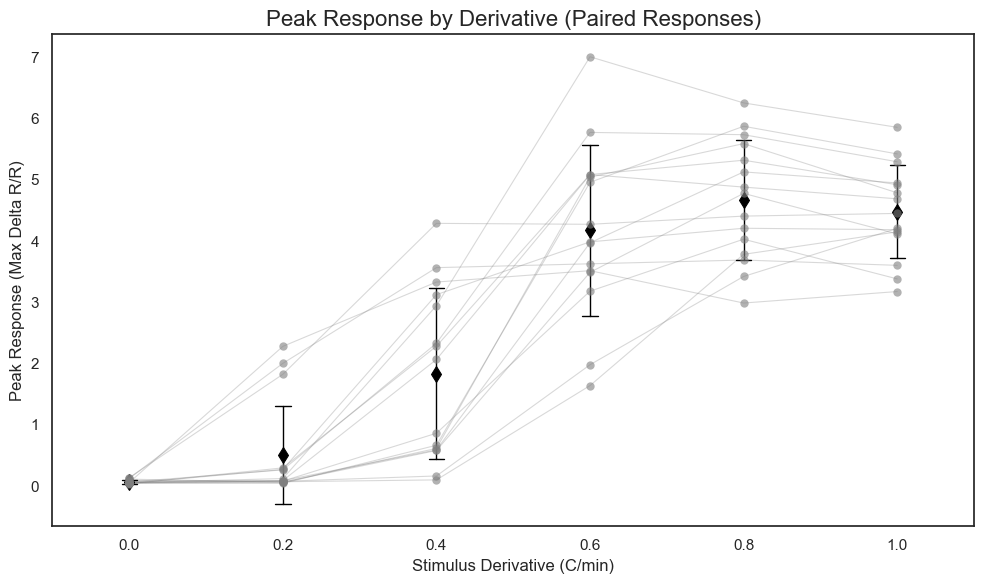

--- Repeated Measures Analysis (Friedman + Wilcoxon-Holm) ---
   -> Excluding columns: ['0.0']

1. Main Test (Friedman):
   Comparing groups: ['0.2', '0.4', '0.6', '0.8', '1.0']
   - Statistic=45.493, p-value=3.14e-09
   -> Significant Difference Found. Proceeding to Post-Hoc...

2. Post-Hoc (Wilcoxon Signed-Rank + Holm Correction):
   -> Mode: One-vs-All (Reference: '0.2')
   - Testing 4 pairs.

 SIGNIFICANT DIFFERENCES (p_adj < 0.05)
Comparison                     | p_adj (Holm) | (p_raw)
------------------------------------------------------------
0.2 vs 0.4                     | 2.44e-04     | (0.00006)
0.2 vs 0.6                     | 2.44e-04     | (0.00006)
0.2 vs 0.8                     | 2.44e-04     | (0.00006)
0.2 vs 1.0                     | 2.44e-04     | (0.00006)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Data 
# 1. Define ranges
ranges_step = [
    (2300, 2900), (3000, 3600), (4200, 4800), 
    (5400, 6000), (6600, 7200), (7800, 8400)
]
stim_mapping = {
     1: "0.0"
    ,2: "0.2"
    ,3: "0.4"
    ,4: "0.6"
    ,5: "0.8"
    ,6: "1.0"
    #,7: "1.2"  
}

df_ramp = get_step_responses_across_replicates(Ramp_Soma, ranges_step, stim_mapping)

# --- CRITICAL FIX: Convert to Categorical Type ---
# This forces ALL plots to respect this numeric order, even lineplot.
x_order = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]

df_ramp['Step_Label'] = pd.Categorical(
    df_ramp['Step_Label'], 
    categories=x_order, 
    ordered=True
)

# --- 3. Create the Plot ---
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# LAYER 1: The Connecting Lines (Spaghetti Plot)
sns.lineplot(
    data=df_ramp,
    x='Step_Label',
    y='Peak_Height',
    units='Replicate_ID', 
    estimator=None,       
    color='gray',
    alpha=0.3,            
    linewidth=0.8
)

# LAYER 2: The Individual Points
sns.stripplot(
    data=df_ramp,
    x='Step_Label',
    y='Peak_Height',
    jitter=False,         # Must be False to align with lines
    alpha=0.6,
    color='gray',
    size=6
)

# LAYER 3: The Mean + SD
sns.pointplot(
    data=df_ramp,
    x='Step_Label',
    y='Peak_Height',
    linestyle='none',
    errorbar='sd',
    color='black',
    capsize=0.1,
    markers='d',
    markersize=8,
    linewidth=1
)

plt.title('Peak Response by Derivative (Paired Responses)', fontsize=16)
plt.xlabel('Stimulus Derivative (C/min)', fontsize=12)
plt.ylabel('Peak Response (Max Delta R/R)', fontsize=12)

plt.tight_layout()
#plt.savefig("C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Immob_Derivative_vs_Ca/UpStep_Response_Paired_Comparison.svg", dpi=600, bbox_inches='tight')
plt.show()

# Run Stats
perform_repeated_measures_analysis(df_ramp, exclude_labels=['0.0'], reference_label='0.2')

## Longer dt

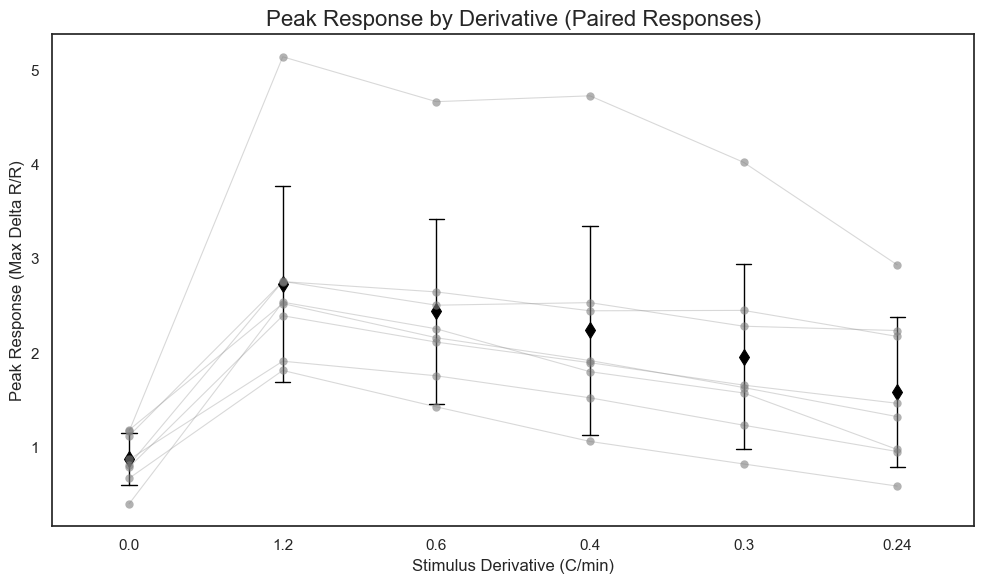

--- Repeated Measures Analysis (Friedman + Wilcoxon-Holm) ---
   -> Excluding columns: ['0.0']

1. Main Test (Friedman):
   Comparing groups: ['0.24', '0.3', '0.4', '0.6', '1.2']
   - Statistic=29.900, p-value=5.13e-06
   -> Significant Difference Found. Proceeding to Post-Hoc...

2. Post-Hoc (Wilcoxon Signed-Rank + Holm Correction):
   -> Mode: One-vs-All (Reference: '1.2')
   - Testing 4 pairs.

 SIGNIFICANT DIFFERENCES (p_adj < 0.05)
Comparison                     | p_adj (Holm) | (p_raw)
------------------------------------------------------------
1.2 vs 0.24                    | 0.03125      | (0.00781)
1.2 vs 0.3                     | 0.03125      | (0.00781)
1.2 vs 0.4                     | 0.03125      | (0.00781)
1.2 vs 0.6                     | 0.03125      | (0.00781)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Data (Assuming functions are loaded)
ranges_dt = [ (500,2000), (2520,5000), (5620,9000), (10020,14400), (15020,20000), (20400,25000)]
stim_mapping = {
     1: "0.0", 2: "1.2", 3: "0.6", 4: "0.4", 5: "0.3", 6: "0.24"
}

df_dt = get_step_responses_across_replicates(DCR3055_Tc25_Longer_dt, ranges_dt, stim_mapping)

# --- CRITICAL FIX: Convert to Categorical Type ---
# This forces ALL plots to respect this numeric order, even lineplot.
x_order = ["0.0", "1.2", "0.6", "0.4", "0.3", "0.24"]

df_dt['Step_Label'] = pd.Categorical(
    df_dt['Step_Label'], 
    categories=x_order, 
    ordered=True
)

# --- 3. Create the Plot ---
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# LAYER 1: The Connecting Lines (Spaghetti Plot)
# Note: We REMOVED 'order=x_order' here. It uses the dataframe's categorical order.
sns.lineplot(
    data=df_dt,
    x='Step_Label',
    y='Peak_Height',
    units='Replicate_ID', 
    estimator=None,       
    color='gray',
    alpha=0.3,            
    linewidth=0.8
    # order=x_order  <-- REMOVED (This caused the crash)
)

# LAYER 2: The Individual Points
sns.stripplot(
    data=df_dt,
    x='Step_Label',
    y='Peak_Height',
    jitter=False,         # Must be False to align with lines
    alpha=0.6,
    color='gray',
    size=6
)

# LAYER 3: The Mean + SD
sns.pointplot(
    data=df_dt,
    x='Step_Label',
    y='Peak_Height',
    linestyle='none',
    errorbar='sd',
    color='black',
    capsize=0.1,
    markers='d',
    markersize=8,
    linewidth=1
)

# --- 4. Final Touches ---
plt.title('Peak Response by Derivative (Paired Responses)', fontsize=16)
plt.xlabel('Stimulus Derivative (C/min)', fontsize=12)
plt.ylabel('Peak Response (Max Delta R/R)', fontsize=12)

plt.tight_layout()
#plt.savefig("C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Immob_Derivative_vs_Ca/dt_Response_Paired_Comparison.svg", dpi=600, bbox_inches='tight')

plt.show()

# Run Stats
perform_repeated_measures_analysis(df_dt, exclude_labels=['0.0'], reference_label='1.2')

## Longer dT

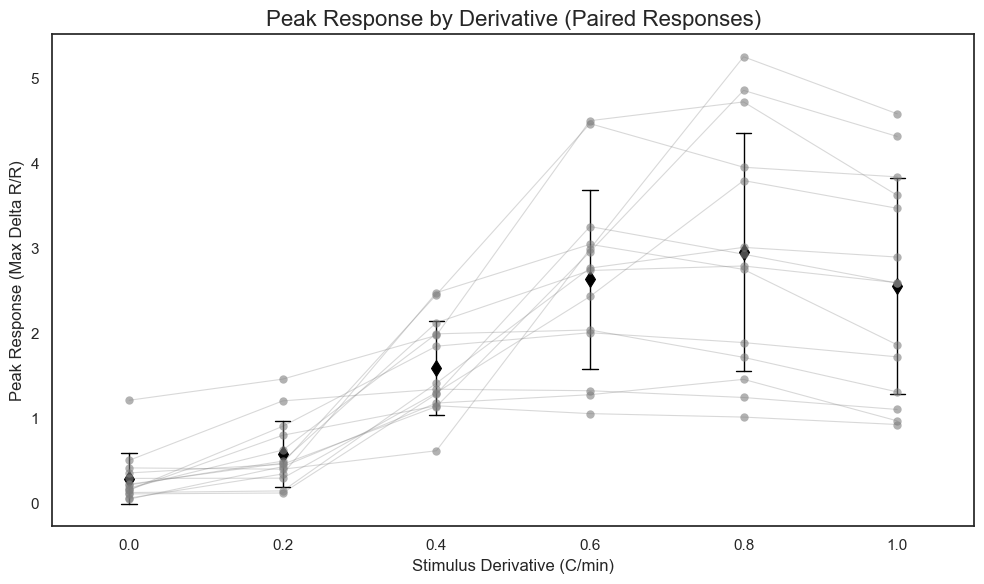

--- Repeated Measures Analysis (Friedman + Wilcoxon-Holm) ---
   -> Excluding columns: ['0.0']

1. Main Test (Friedman):
   Comparing groups: ['0.2', '0.4', '0.6', '0.8', '1.0']
   - Statistic=37.029, p-value=1.78e-07
   -> Significant Difference Found. Proceeding to Post-Hoc...

2. Post-Hoc (Wilcoxon Signed-Rank + Holm Correction):
   -> Mode: One-vs-All (Reference: '0.2')
   - Testing 4 pairs.

 SIGNIFICANT DIFFERENCES (p_adj < 0.05)
Comparison                     | p_adj (Holm) | (p_raw)
------------------------------------------------------------
0.2 vs 0.4                     | 4.88e-04     | (0.00012)
0.2 vs 0.6                     | 4.88e-04     | (0.00012)
0.2 vs 0.8                     | 4.88e-04     | (0.00012)
0.2 vs 1.0                     | 4.88e-04     | (0.00024)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Data (Assuming functions are loaded)
ranges_dT = [ (1500,2400), (2700,4700), (5800,7900), (10000,12500), (13000,15000), (16500,20000) 
             ]
stim_mapping = {
     1: "0.0"
    ,2: "0.2"
    ,3: "0.4"
    ,4: "0.6"
    ,5: "0.8"
    ,6: "1.0"
    #,7: "1.2"  
}

df_dT = get_step_responses_across_replicates(DCR3055_Tc25_Longer_dT, ranges_dT, stim_mapping)

# --- CRITICAL FIX: Convert to Categorical Type ---
# This forces ALL plots to respect this numeric order, even lineplot.
x_order = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]

df_dT['Step_Label'] = pd.Categorical(
    df_dT['Step_Label'], 
    categories=x_order, 
    ordered=True
)

# --- 3. Create the Plot ---
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# LAYER 1: The Connecting Lines (Spaghetti Plot)
# Note: We REMOVED 'order=x_order' here. It uses the dataframe's categorical order.
sns.lineplot(
    data=df_dT,
    x='Step_Label',
    y='Peak_Height',
    units='Replicate_ID', 
    estimator=None,       
    color='gray',
    alpha=0.3,            
    linewidth=0.8
    # order=x_order  <-- REMOVED (This caused the crash)
)

# LAYER 2: The Individual Points
sns.stripplot(
    data=df_dT,
    x='Step_Label',
    y='Peak_Height',
    jitter=False,         # Must be False to align with lines
    alpha=0.6,
    color='gray',
    size=6
)

# LAYER 3: The Mean + SD
sns.pointplot(
    data=df_dT,
    x='Step_Label',
    y='Peak_Height',
    linestyle='none',
    errorbar='sd',
    color='black',
    capsize=0.1,
    markers='d',
    markersize=8,
    linewidth=1
)

# --- 4. Final Touches ---
plt.title('Peak Response by Derivative (Paired Responses)', fontsize=16)
plt.xlabel('Stimulus Derivative (C/min)', fontsize=12)
plt.ylabel('Peak Response (Max Delta R/R)', fontsize=12)

plt.tight_layout()
#plt.savefig("C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Immob_Derivative_vs_Ca/dT_Response_Paired_Comparison.svg", dpi=600, bbox_inches='tight')

plt.show()

# Run Stats
perform_repeated_measures_analysis(df_dT, exclude_labels=['0.0'], reference_label='0.2')